<a href="https://colab.research.google.com/github/androsel00/NeuronalNetworks_Team16/blob/main/Gapminder_Team16_Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Google Colab Runtime Version:** 2026.04 <br>
Ubuntu 22.04.5 LTS <br>
Python 3.12.13 <br>
numpy 2.0.2 <br>
PyTorch 2.10.0 <br>
Jax 0.7.2 <br>
TensorFlow 2.19.0 (not included in TPU runtimes) <br>
R version 4.5.3 (2026-03-11) -- "Reassured Reassurer" <br>
julia version 1.11.5 <br>

First we need some packages. Some that are very useful and used in class are:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (6, 5)

We are using the Gapminder data set, which you can find here: <br>

`https://www.gapminder.org/data/documentation/`


target variable `y` in gapminder = `lifeExpectancy`

In [ ]:
gapminder = px.data.gapminder()
display(gapminder.head())

target_name = 'lifeExp'
feature_names = ['pop', 'gdpPercap', 'year']   # numeric features

y = gapminder[target_name].values
X = gapminder[feature_names].values

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


In [ ]:
df = pd.DataFrame(X, columns=feature_names)
df["continent"] = gapminder["continent"].values
df["lifeExp"] = y
print(df.head(3))

          pop   gdpPercap    year continent  lifeExp
0   8425333.0  779.445314  1952.0      Asia   28.801
1   9240934.0  820.853030  1957.0      Asia   30.332
2  10267083.0  853.100710  1962.0      Asia   31.997


In [ ]:
print('Overall summary:')
print(df.describe(include="all"))

Overall summary:
                 pop      gdpPercap        year continent      lifeExp
count   1.704000e+03    1704.000000  1704.00000      1704  1704.000000
unique           NaN            NaN         NaN         5          NaN
top              NaN            NaN         NaN    Africa          NaN
freq             NaN            NaN         NaN       624          NaN
mean    2.960121e+07    7215.327081  1979.50000       NaN    59.474439
std     1.061579e+08    9857.454543    17.26533       NaN    12.917107
min     6.001100e+04     241.165876  1952.00000       NaN    23.599000
25%     2.793664e+06    1202.060309  1965.75000       NaN    48.198000
50%     7.023596e+06    3531.846989  1979.50000       NaN    60.712500
75%     1.958522e+07    9325.462346  1993.25000       NaN    70.845500
max     1.318683e+09  113523.132900  2007.00000       NaN    82.603000


In [ ]:
print('Summary by continent:')
print(df.groupby("continent").describe())

Summary by continent:
             pop                                                     \
           count          mean           std        min         25%   
continent                                                             
Africa     624.0  9.916003e+06  1.549092e+07    60011.0  1342075.00   
Americas   300.0  2.450479e+07  5.097943e+07   662850.0  2962358.75   
Asia       396.0  7.703872e+07  2.068852e+08   120447.0  3844393.00   
Europe     360.0  1.716976e+07  2.051944e+07   147962.0  4331500.00   
Oceania     24.0  8.874672e+06  6.506342e+06  1994794.0  3199212.50   

                                                 gdpPercap                ...  \
                  50%          75%           max     count          mean  ...   
continent                                                                 ...   
Africa      4579311.0  10801489.75  1.350312e+08     624.0   2193.754578  ...   
Americas    6227510.0  18340309.00  3.011399e+08     300.0   7136.110356  ...   
Asia

In [ ]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[feature_names]), columns=feature_names)
df_scaled["continent"] = df["continent"].values

In [ ]:
all_numeric = feature_names + ['lifeExp']
df_scaled = pd.DataFrame(scaler.fit_transform(df[all_numeric]), columns=all_numeric)
df_scaled["continent"] = df["continent"].values

In [ ]:
df_long = df_scaled.melt(
    id_vars="continent",
    value_vars=all_numeric,
    var_name="Feature",
    value_name="Value"
)

print(f"Wide format. df.shape = {df.shape}")
print(df.head(3))
print(f"Long format. df_long.shape = {df_long.shape}")
print(df_long.head(3))

Wide format. df.shape = (1704, 5)
          pop   gdpPercap    year continent  lifeExp
0   8425333.0  779.445314  1952.0      Asia   28.801
1   9240934.0  820.853030  1957.0      Asia   30.332
2  10267083.0  853.100710  1962.0      Asia   31.997
Long format. df_long.shape = (6816, 3)
  continent Feature     Value
0      Asia     pop -0.199534
1      Asia     pop -0.191849
2      Asia     pop -0.182180


removed year here, cause it looks weird when you keep it and made a separate figure

/tmp/ipykernel_1076/3709312112.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


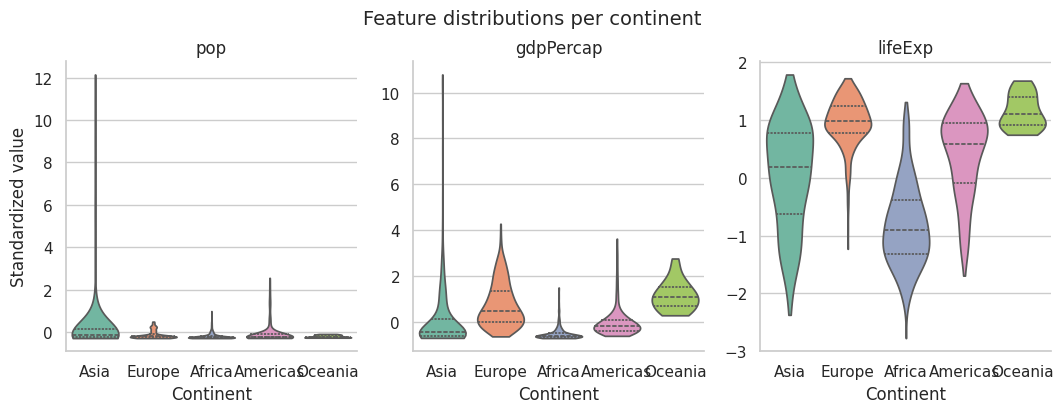

In [ ]:
g = sns.catplot(
    data=df_long[df_long["Feature"] != "year"],
    x="continent", y="Value",
    col="Feature",                 # one subplot per feature
    kind="violin",
    inner="quartile",
    cut=0,
    palette="Set2",
    height=4, aspect=0.9,
    sharey=False                   # let each feature have its own y-axis
)

g.set_titles("{col_name}")
g.set_axis_labels("Continent", "Standardized value")
g.fig.suptitle("Feature distributions per continent", y=1.03, fontsize=14)
plt.show()

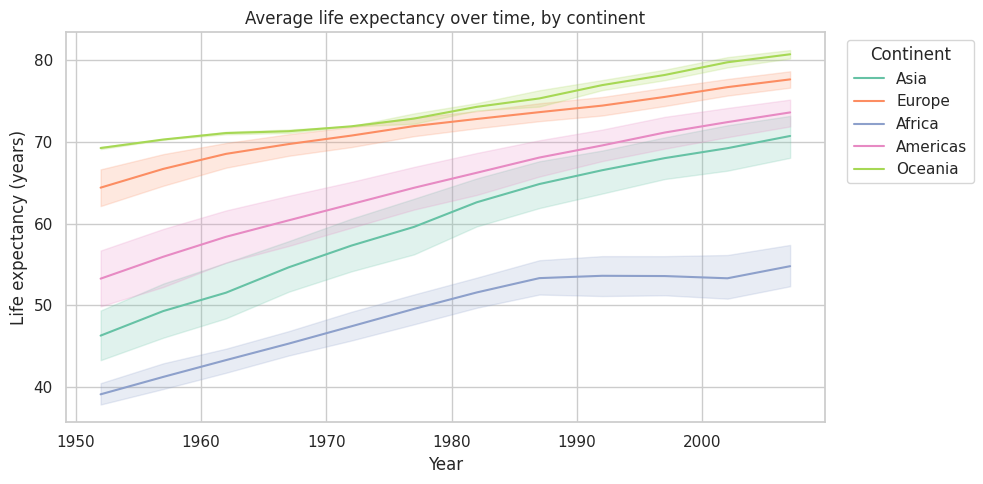

In [ ]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=gapminder,
    x="year", y="lifeExp",
    hue="continent",
    estimator="mean",
    errorbar=("ci", 95),
    palette="Set2"
)
plt.title("Average life expectancy over time, by continent")
plt.xlabel("Year")
plt.ylabel("Life expectancy (years)")
plt.legend(title="Continent", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

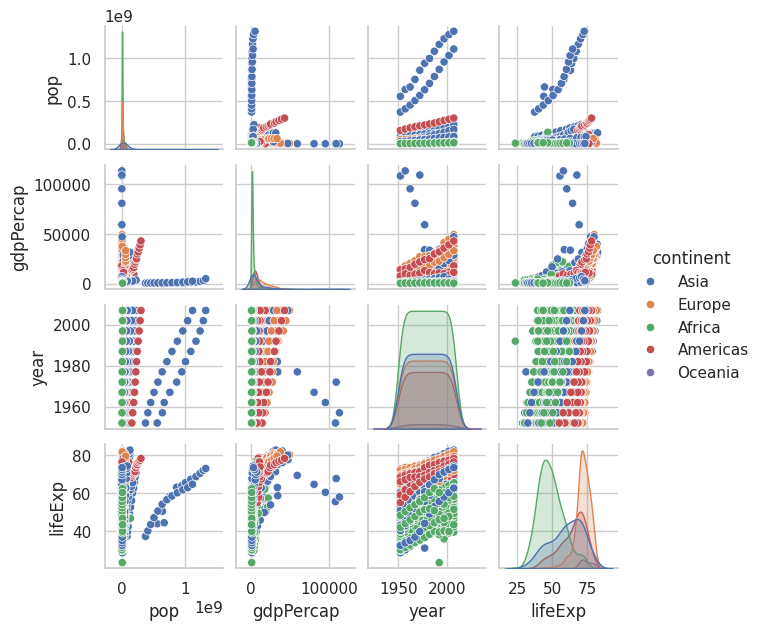

In [ ]:
sns.pairplot(df, hue="continent", height=1.6)
plt.show()

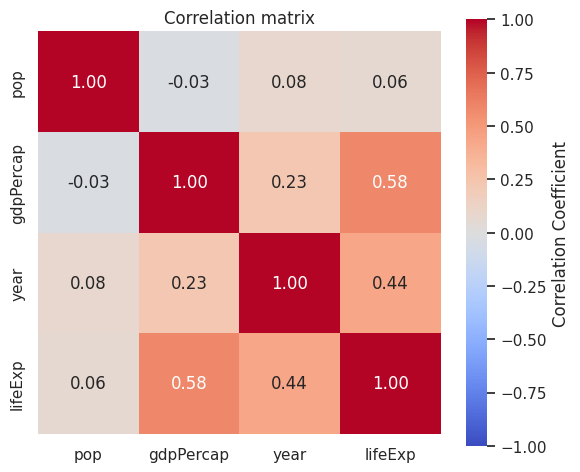

In [ ]:
corr = df[feature_names + ['lifeExp']].corr()

plt.figure()
sns.heatmap(corr,
    vmin=-1, vmax=1,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    square=True,
    cbar_kws={"label": "Correlation Coefficient"}
)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()